## 1. Librerías
Importación de las librerías necesarias para el procesamiento y visualización de datos.

In [68]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 2. Carga de datos
Se carga la tabla `ENEMDU_2024_Participacion` exportada desde SQL Server como archivo `.txt` con separador `;`. Las columnas conservan los códigos originales del cuestionario ENEMDU.

In [69]:
# Cargar datos
df = pd.read_csv(r"C:\Users\Usuario iTC\Desktop\SQL Curso\Proyectos\2. ecos_ec\base de datos\2024\Enemdu personas\ENEMDU_2024_Participacion_Raw.txt", delimiter=';')
df.head()

,mes,periodo,p54,grupo1,p42,rama1,p36,condact,p23,p25,...,area,prov,p02,p03,fexp,pobreza,ingrl,ingpc,p24,id_persona
0,12,202412,0,"9,00",10,"20,00",0,"4,00",0,0,...,1,"24,00",2,33,"57,13",",00","420,00","180,00",40,2401500073030480510112
1,12,202412,0,NaN,0,NaN,3,"9,00",0,0,...,1,"24,00",2,15,"57,13",",00",NaN,"180,00",0,2401500073030480510212
2,12,202412,0,NaN,0,NaN,3,",00",0,0,...,1,"24,00",2,13,"57,13",",00",NaN,"180,00",0,2401500073030480510312
3,12,202412,0,"9,00",4,"6,00",0,"4,00",0,0,...,1,"24,00",1,25,"57,13",",00","230,00","180,00",45,2401500073030480510412
4,12,202412,0,"9,00",10,"20,00",0,"4,00",0,0,...,1,"24,00",2,24,"57,13",",00","420,00","180,00",40,2401500073030480510512


## 3. Exploración inicial
Inspección de valores únicos en variables categóricas clave para entender la codificación numérica original del cuestionario ENEMDU antes de la decodificación.

In [70]:
#valores unicos p02
df['p02'].unique()

array([2, 1])

In [71]:
#valores unicos condact
df['condact'].unique()

array(['4,00', '9,00', ',00', '2,00', '1,00', '5,00', '8,00', '7,00',
       '6,00', '3,00'], dtype=object)

In [72]:
# valores unicos rama1
df['rama1'].unique()

array(['20,00', nan, '6,00', '7,00', '8,00', '1,00', '14,00', '17,00',
       '9,00', '3,00', '16,00', '18,00', '19,00', '15,00', '5,00', '4,00',
       '12,00', '13,00', '2,00', '10,00', '11,00', '22,00', '21,00'],
      dtype=object)

In [73]:
# Tipos de datos
df.dtypes

mes            int64
periodo        int64
p54            int64
grupo1        object
p42            int64
rama1         object
p36            int64
condact       object
p23            int64
p25            int64
p26            int64
p27            int64
p28            int64
p07            int64
p09            int64
p10a           int64
nnivins       object
p06            int64
p05a           int64
p05b           int64
ciudad         int64
area           int64
prov          object
p02            int64
p03            int64
fexp          object
pobreza       object
ingrl         object
ingpc         object
p24            int64
id_persona    object
dtype: object

## 4. Conversión de tipos numéricos
Las columnas `ingpc`, `ingrl` y `fexp` vienen como texto con coma decimal (formato europeo). Se normalizan a punto y se convierten a `float` con `pd.to_numeric`. Errores de conversión se convierten en `NaN`.

In [74]:
# Convertir ingpc, ingprl y fexp a decimales y edad a entero
# Reemplazar comas por puntos 
df['ingpc'] = df['ingpc'].astype(str).str.replace(',', '.').str.strip()
df['ingrl'] = df['ingrl'].astype(str).str.replace(',', '.').str.strip()
df['fexp'] = df['fexp'].astype(str).str.replace(',', '.').str.strip()
# Convertir sting a numeric
df['ingpc'] = pd.to_numeric(df['ingpc'], errors='coerce')
df['ingrl'] = pd.to_numeric(df['ingrl'], errors='coerce')
df['fexp'] = pd.to_numeric(df['fexp'], errors='coerce')

## 5. Estadísticas descriptivas
Resumen estadístico general del DataFrame para detectar rangos inusuales y confirmar los tipos de datos antes de la limpieza.

In [75]:
# Descripción general del DataFrame
df.describe()

,mes,periodo,p54,p42,p36,p23,p25,p26,p27,p28,...,p05a,p05b,ciudad,area,p02,p03,fexp,ingrl,ingpc,p24
count,320973.000000,320973.000000,320973.000000,320973.000000,320973.000000,320973.000000,320973.000000,320973.000000,320973.000000,320973.000000,...,320973.000000,320973.000000,320973.000000,320973.000000,320973.000000,320973.000000,320973.000000,146891.000000,320973.000000,320973.000000
mean,6.478171,202406.478171,0.220461,2.358002,1.490901,0.031246,0.844900,0.313868,1.733395,0.118078,...,6.804893,9.930047,117347.417449,1.266424,1.519019,37.925034,53.383954,1644.714285,311.657684,17.949220
std,3.442661,3.442661,1.149545,2.766474,1.740063,0.394968,2.114527,0.565162,1.881509,0.330589,...,4.146323,0.592929,65378.327105,0.442089,0.499639,21.811333,107.506974,33178.417489,346.335924,20.246097
min,1.000000,202401.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,4.000000,10150.000000,1.000000,1.000000,5.000000,0.500000,-1.000000,0.600000,0.000000
25%,3.000000,202403.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,10.000000,70150.000000,1.000000,1.000000,19.000000,9.040000,200.000000,118.000000,0.000000
50%,6.000000,202406.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,10.000000,100300.000000,1.000000,2.000000,35.000000,21.900000,450.000000,210.000000,8.000000
75%,9.000000,202409.000000,0.000000,6.000000,3.000000,0.000000,0.000000,1.000000,4.000000,0.000000,...,10.000000,10.000000,170155.000000,2.000000,2.000000,55.000000,51.930000,660.000000,381.250000,40.000000
max,12.000000,202412.000000,10.000000,10.000000,6.000000,7.000000,9.000000,5.000000,4.000000,2.000000,...,10.000000,10.000000,240352.000000,2.000000,2.000000,98.000000,2243.150000,999999.000000,9030.000000,120.000000


## 6. Detección y eliminación del valor centinela en ingreso laboral
El valor `999999.0` es el código que usa el INEC para representar ingresos no declarados o no aplicables (p. ej., personas sin empleo). Se cuantifica y luego se elimina del dataset.

In [76]:
# Numero de filas con ingrl igual a 999999.0
df[df['ingrl'] == 999999.0].shape[0]

162

In [77]:
# p06 valores únicos
df['p06'].unique()

array([2, 6, 5, 4, 0, 1, 3])

In [78]:
# ver p06 cuadno es 0 numeor de filas 
df[df['p06'] == 0].shape[0]

34213

## 7. Análisis de outliers y winsorización
Se aplica **winsorización** (recorte por percentiles p1–p99) a `ingrl` e `ingpc` para reducir el efecto de valores extremos sin eliminar observaciones. El número total de filas se conserva igual que antes de la limpieza.

In [79]:
# Eliminar valores ingrl con datos faltantes 999999.0 
df = df[df['ingrl'] != 999999.0]

<Axes: ylabel='ingrl'>

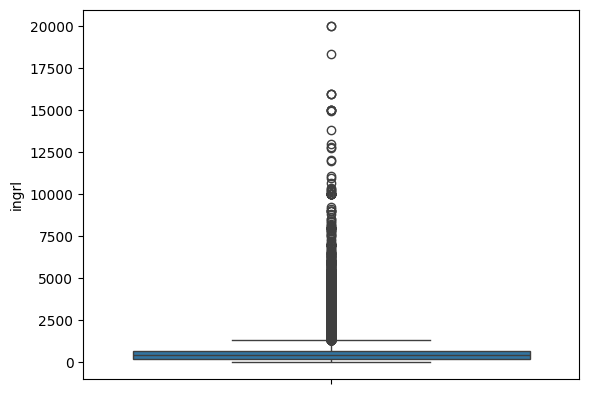

In [80]:
# Grafico de caja ingprl
sns.boxplot(y = "ingrl", data = df)

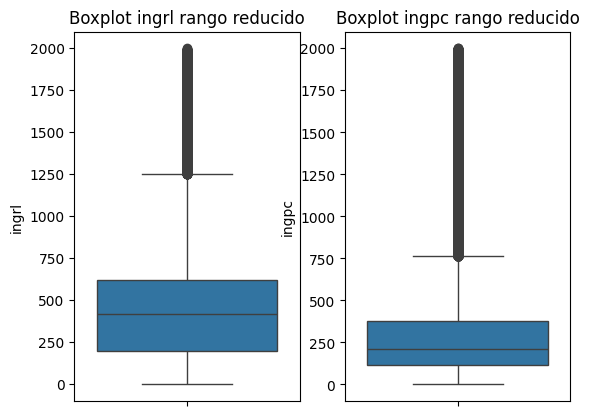

In [81]:
# Grafico de caja ingrl y ingpc con rango reducido 2000
fig, axes = plt.subplots(1, 2)
sns.boxplot(y = "ingrl", data = df[df['ingrl'] < 2000], ax=axes[0])
axes[0].set_title('Boxplot ingrl rango reducido')

sns.boxplot(y = "ingpc", data = df[df['ingpc'] < 2000], ax=axes[1])
axes[1].set_title('Boxplot ingpc rango reducido')
plt.show()

In [82]:
# Columna a analizar ingpc
columna_analizar = "ingrl"
# calcular Q1, Q2 y Q3
Q1 = df[columna_analizar].quantile(0.25)
Q2 = df[columna_analizar].quantile(0.50)
Q3 = df[columna_analizar].quantile(0.75)
# calcular IQR
IQR = Q3 - Q1
# definir el limite superior e inferior
limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR
# detectar outliers
outliers = df[(df[columna_analizar] < limite_inferior) | (df[columna_analizar] > limite_superior)]
print(outliers.shape[0])

9178


In [83]:
# percentiles suaves
p1 = df["ingrl"].quantile(0.01)
p99 = df["ingrl"].quantile(0.99)

print(p1, p99)

# winsorization
data4 = df.copy()
data4["ingrl"] = df["ingrl"].clip(p1, p99)

0.0 2800.0


## 8. Visualización post-winsorización
Verificación gráfica mediante histogramas y boxplots para confirmar que la distribución de los ingresos es razonable tras la winsorización.

In [84]:
cols_cont = ['ingpc', 'ingrl']

P1 = df[cols_cont].quantile(0.01)
P99 = df[cols_cont].quantile(0.99)

print(P1, P99)

ingpc    20.83
ingrl     0.00
Name: 0.01, dtype: float64 ingpc    1666.67
ingrl    2800.00
Name: 0.99, dtype: float64


In [85]:
# Crear copia del DataFrame original
data1 = df.copy()
# Aplicar winsorization
data1[cols_cont] = data1[cols_cont].clip(lower=P1, upper=P99, axis=1)

In [86]:
# numero de registros ingrl antes y despues de winsorization ingrl
data1['ingrl'].shape[0], df['ingrl'].shape[0]

(320811, 320811)

In [87]:
# describe el DataFrame modificado
data1[cols_cont].describe()

,ingpc,ingrl
count,320811.000000,146729.000000
mean,304.416472,529.115512
std,291.839108,491.439845
min,20.830000,0.000000
25%,118.000000,200.000000
50%,210.000000,450.000000
75%,381.250000,660.000000
max,1666.670000,2800.000000


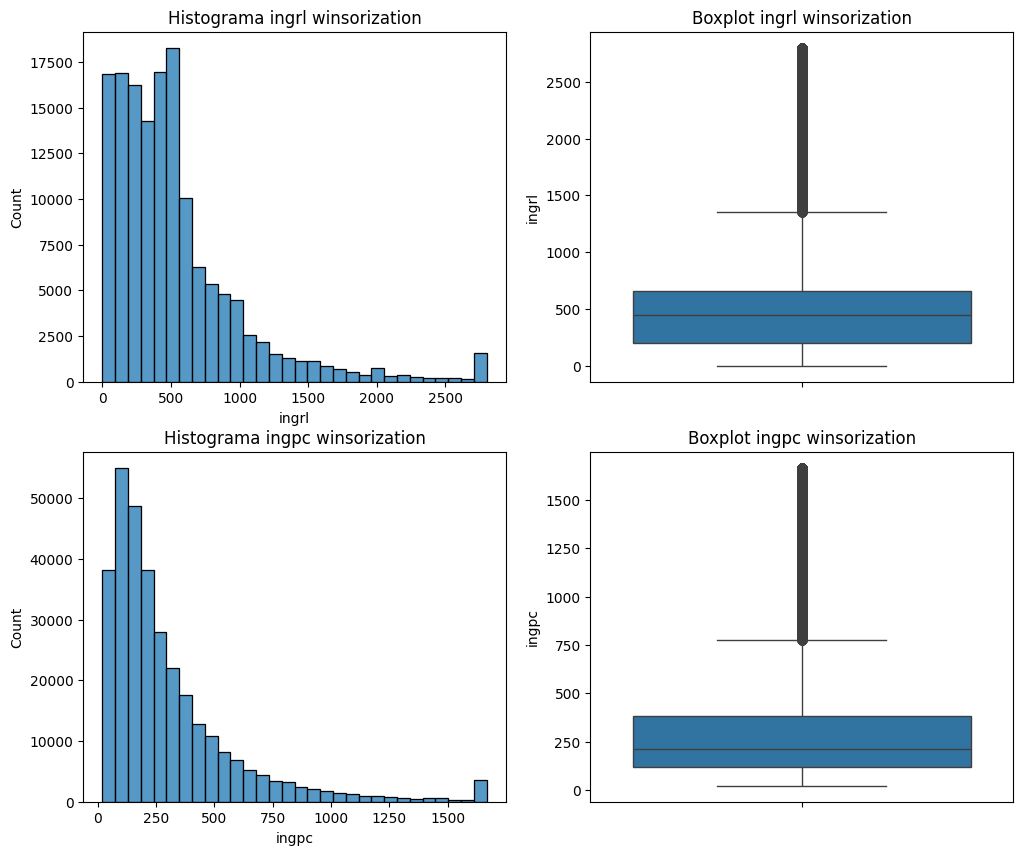

In [88]:
# Grafico despues de winsorization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(x = "ingrl", data = data1,bins = 30,  ax=axes[0, 0])
axes[0, 0].set_title('Histograma ingrl winsorization')

sns.boxplot(y = "ingrl", data = data1, ax=axes[0, 1])
axes[0, 1].set_title('Boxplot ingrl winsorization')

sns.histplot(x = "ingpc", data = data1,bins = 30,  ax=axes[1, 0])
axes[1, 0].set_title('Histograma ingpc winsorization')

sns.boxplot(y = "ingpc", data = data1, ax=axes[1, 1])
axes[1, 1].set_title('Boxplot ingpc winsorization')
plt.show()

In [89]:
data1.describe()

,mes,periodo,p54,p42,p36,p23,p25,p26,p27,p28,...,p05a,p05b,ciudad,area,p02,p03,fexp,ingrl,ingpc,p24
count,320811.000000,320811.000000,320811.000000,320811.000000,320811.000000,320811.000000,320811.000000,320811.000000,320811.000000,320811.000000,...,320811.000000,320811.000000,320811.000000,320811.000000,320811.000000,320811.000000,320811.000000,146729.000000,320811.000000,320811.000000
mean,6.478188,202406.478188,0.220320,2.357164,1.491654,0.031208,0.844893,0.313596,1.732437,0.118063,...,6.805979,9.930242,117332.912104,1.266490,1.519128,37.921066,53.393008,529.115512,304.416472,17.937515
std,3.442744,3.442744,1.149232,2.766551,1.740179,0.394760,2.114505,0.565036,1.881380,0.330557,...,4.146008,0.592141,65378.904498,0.442124,0.499635,21.814011,107.527816,491.439845,291.839108,20.242470
min,1.000000,202401.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,4.000000,10150.000000,1.000000,1.000000,5.000000,0.500000,0.000000,20.830000,0.000000
25%,3.000000,202403.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,10.000000,70150.000000,1.000000,1.000000,19.000000,9.040000,200.000000,118.000000,0.000000
50%,6.000000,202406.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,10.000000,100300.000000,1.000000,2.000000,35.000000,21.900000,450.000000,210.000000,8.000000
75%,9.000000,202409.000000,0.000000,6.000000,3.000000,0.000000,0.000000,1.000000,4.000000,0.000000,...,10.000000,10.000000,170155.000000,2.000000,2.000000,55.000000,51.930000,660.000000,381.250000,40.000000
max,12.000000,202412.000000,10.000000,10.000000,6.000000,7.000000,9.000000,5.000000,4.000000,2.000000,...,10.000000,10.000000,240352.000000,2.000000,2.000000,98.000000,2243.150000,2800.000000,1666.670000,120.000000


## 9. Transformación de variables categóricas
Conversión de todos los códigos numéricos del cuestionario a etiquetas descriptivas en español, usando diccionarios de mapeo basados en el diccionario de variables de la ENEMDU (INEC). Se renombran las columnas a nombres descriptivos.

In [90]:
# Conversion de variables categoricas a tipo category
# Mes y Periodo Transformaciones
# Cambiar nombre de mes y periodo
data1 = data1.rename(columns={
    "mes": "Mes",
    "periodo": "Periodo"
})
# Mes nombre, mes abreviado y cuartil
# Diccionarios de nombres completos y abreviaturas
meses_nombre = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
    5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}

meses_abreviados = {
    1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Ago",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
}

cuartiles = {
    1: "Q1", 2: "Q1", 3: "Q1",
    4: "Q2", 5: "Q2", 6: "Q2",
    7: "Q3", 8: "Q3", 9: "Q3",
    10: "Q4", 11: "Q4", 12: "Q4"
}

# Crear columnas en df_limpio
data1["Mes_nombre"] = data1["Mes"].map(meses_nombre)
data1["Mes_abreviado"] = data1["Mes"].map(meses_abreviados)
data1["Mes_cuartil"] = data1["Mes"].map(cuartiles)


In [ ]:
# Renombrar la columna
data1 = data1.rename(columns={"rama1": "Rama_actividad"})

# Diccionario de ramas de actividad
ramas_actividad = {
    "1,00": "A. Agricultura, ganadería caza y silvicultura y pesca",
    "2,00": "B. Explotación de minas y canteras",
    "3,00": "C. Industrias manufactureras",
    "4,00": "D. Suministros de electricidad, gas, aire acondicionado",
    "5,00": "E. Distribución de agua, alcantarillado",
    "6,00": "F. Construcción",
    "7,00": "G. Comercio, reparación vehículos",
    "8,00": "H. Transporte y almacenamiento",
    "9,00": "I. Actividades de alojamiento y servicios de comida",
    "10,00": "J. Información y comunicación",
    "11,00": "K. Actividades financieras y de seguros",
    "12,00": "L. Actividades inmobiliarias",
    "13,00": "M. Actividades profesionales, científicas y técnicas",
    "14,00": "N. Actividades y servicios administrativos y de apoyo",
    "15,00": "O. Administración pública, defensa y seguridad social",
    "16,00": "P. Enseñanza",
    "17,00": "Q. Actividades, servicios sociales y de salud",
    "18,00": "R. Artes, entretenimiento y recreación",
    "19,00": "S. Otras actividades de servicios",
    "20,00": "T. Actividades en hogares privados con servicio doméstico",
    "21,00": "U. Actividades de organizaciones extraterritoriales",
    "22,00": "No especificado"
}

# Limpiar y mapear
data1["Rama_actividad"] = data1["Rama_actividad"].astype(str).str.strip()
data1["Rama_actividad"] = data1["Rama_actividad"].map(ramas_actividad)

# Reemplazar NaN por "Desconocido"
data1["Rama_actividad"] = data1["Rama_actividad"].fillna("Desconocido")

# Mostrar conteo
print(data1["Rama_actividad"].value_counts(dropna=False))




Rama_actividad
Desconocido                                                  156662
A. Agricultura, ganadería caza y silvicultura y pesca         39972
G. Comercio, reparación vehículos                             31175
C. Industrias manufactureras                                  16370
I. Actividades de alojamiento y servicios de comida           11875
H. Transporte y almacenamiento                                 9607
F. Construcción                                                9075
P. Enseñanza                                                   8057
O. Administración pública, defensa y seguridad social          6377
Q. Actividades, servicios sociales y de salud                  5622
N. Actividades y servicios administrativos y de apoyo          5501
S. Otras actividades de servicios                              4652
T. Actividades en hogares privados con servicio doméstico      4236
M. Actividades profesionales, científicas y técnicas           4124
K. Actividades financieras y de s

In [92]:
# Tansformación p06 - Estado civil
data1 = data1.rename(columns={
    "p06": "Estado_civil"
})
# Diccionarios de nombres completos y abreviaturas
Estado_civil_dict = {
    0 : "No definido",
    1 : "Casados(a)",
    2 : "Separado(a)",
    3 : "Divorciado(a)",
    4 : "Viudo(a)",
    5 : "Unión Libre",
    6 : "Soltero(a)"
}
# Remplazar valores en la columna Estado_civil
data1["Estado_civil"] = data1["Estado_civil"].map(Estado_civil_dict)
#Verificar la transformación
print(data1["Estado_civil"].value_counts())

Estado_civil
Soltero(a)       116303
Casados(a)        83299
Unión Libre       45102
No definido       34213
Separado(a)       16628
Viudo(a)          14943
Divorciado(a)     10323
Name: count, dtype: int64


In [93]:
# Transformar p42 a Categoría de ocupación
# Cambiar nombre de columna p42 a Categoria_ocupacion
data1 = data1.rename(columns={
    "p42": "Categoria_ocupacion"
})
# Diccionario de categorías de ocupación
Categoria_ocupacion_dict = {
    1 : "Empleado de gobierno",
    2 : "Empleado privado",
    3 : "Empleado tercerizado",
    4 : "Jornalero o peón",
    5 : "Patrón",
    6 : "Cuenta Propia",
    7 : "Trabajador del hogar no remunerado",
    8 : "Trabajador no del hogar no remunerado",
    9 : "Ayuda no remunerada de asalariado/jornalero",
    10 : "Empleado(a) Doméstico"
}
# Remplazar valores en la columna Categoria_ocupacion
data1["Categoria_ocupacion"] = data1["Categoria_ocupacion"].map(Categoria_ocupacion_dict)
#Verificar la transformación
print(data1["Categoria_ocupacion"].value_counts())

Categoria_ocupacion
Cuenta Propia                                  60173
Empleado privado                               51030
Trabajador del hogar no remunerado             20179
Empleado de gobierno                           15616
Jornalero o peón                               15461
Patrón                                          4806
Empleado(a) Doméstico                           4529
Trabajador no del hogar no remunerado            363
Ayuda no remunerada de asalariado/jornalero      241
Name: count, dtype: int64


In [94]:
#Trasnformar ingpc y ingrl
# Cambiar nombres de columnas
data1 = data1.rename(columns={
    "ingpc": "Ingreso_per_capita",
    "ingrl": "Ingreso_laboral"
})

In [95]:
# Tansformación p24 a Horas de trabajo la semana pasada
# Cambiar nombre de columna p24 a Horas_trabajo_semana_pasada
data1 = data1.rename(columns={
    "p24": "Horas_trabajo_semana_pasada"
})

In [96]:
# Tansformación condact a Condición de actividad laboral
# Cambiar nombre de columna condact a Condicion_actividad_laboral
data1 = data1.rename(columns={
    "condact": "Condicion_actividad_laboral"
})
# Diccionario de condición de actividad laboral
Condicion_actividad_laboral_dict = {
    ",00" : "Menores de 15 años",
    "1,00" : "Empleado Adecuado/Pleno",
    "2,00" : "Subempleo por insuficiencia de tiempo de trabajo",
    "3,00" : "Subempleo por insuficiencia de ingreso",
    "4,00" : "Otro empleo no pleno",
    "5,00" : "Empleo no remunerado",
    "6,00" : "Empleo no clasificado",
    "7,00" : "Desempleo abierto",
    "8,00" : "Desempleo oculto",
    "9,00" : "Población económicamente inactiva",
}
# Remplazar valores en la columna Condicion_actividad_laboral
data1["Condicion_actividad_laboral"] = data1["Condicion_actividad_laboral"].map(Condicion_actividad_laboral_dict)
#Verificar la transformación
print(data1["Condicion_actividad_laboral"].value_counts())

Condicion_actividad_laboral
Población económicamente inactiva                   95914
Empleado Adecuado/Pleno                             69252
Menores de 15 años                                  52779
Otro empleo no pleno                                47488
Subempleo por insuficiencia de tiempo de trabajo    30338
Empleo no remunerado                                14722
Desempleo abierto                                    7204
Subempleo por insuficiencia de ingreso               2349
Desempleo oculto                                      765
Name: count, dtype: int64


In [97]:
# Transoformar p02 a Sexo
# Cambiar nombre de columna p02 a Sexo
data1 = data1.rename(columns={
    "p02": "Sexo"
})
# Diccionario de sexo
Sexo_dict = {
    1 : "Hombre",
    2 : "Mujer"
}
# Remplazar valores en la columna Sexo
data1["Sexo"] = data1["Sexo"].map(Sexo_dict)
#Verificar la transformación
print(data1["Sexo"].value_counts())

Sexo
Mujer     166542
Hombre    154269
Name: count, dtype: int64


In [98]:
# Transformación p10a - Nivel de instrucción
# Cambiar nombre de columna p10a a Nivel_instruccion_Compuesto
data1 = data1.rename(columns={
    "p10a": "Nivel_instruccion_Compuesto"
})
# Diccionario de nivel de instrucción
Nivel_instruccion_Compuesto_dict = {
1 : "Ninguno",
2 : "Centro de alfabetización",
3 : "Jardín de infantes",
4 : "Primaria",
5 : "Educación Básica",
6 : "Secundaria",
7 : "Educación Media",
8 : "Superior no universitario",
9 : "Superior Universitario",
10 : "Post-grado",
}
# Remplazar valores en la columna Nivel_instruccion_Compuesto
data1["Nivel_instruccion_Compuesto"] = data1["Nivel_instruccion_Compuesto"].map(Nivel_instruccion_Compuesto_dict)
#Verificar la transformación
print(data1["Nivel_instruccion_Compuesto"].value_counts())

Nivel_instruccion_Compuesto
Secundaria                   67038
Primaria                     66191
Educación Básica             65105
Superior Universitario       52687
Educación Media              43538
Superior no universitario     9194
Ninguno                       8994
Post-grado                    7685
Centro de alfabetización       379
Name: count, dtype: int64


In [99]:
# Transformar nnivins a Nivel de instrucción simple
# Cambiar nombre de columna nnivins a Nivel_instruccion_Simple
data1 = data1.rename(columns={
    "nnivins": "Nivel_instruccion_Simple"
})
# Diccionario de nivel de instrucción simple
Nivel_instruccion_Simple_dict = {
    "1,00" : "Ninguno",
    "2,00" : "Centro de Alfabetización",
    "3,00" : "Educación Básica",
    "4,00" : "Educación Media/Bachillerato",
    "5,00" : "Superior",
}
# Remplazar valores en la columna Nivel_instruccion_Simple
data1["Nivel_instruccion_Simple"] = data1["Nivel_instruccion_Simple"].map(Nivel_instruccion_Simple_dict)
#Verificar la transformación
print(data1["Nivel_instruccion_Simple"].value_counts())

Nivel_instruccion_Simple
Educación Básica                145121
Educación Media/Bachillerato     96751
Superior                         69566
Ninguno                           8994
Centro de Alfabetización           379
Name: count, dtype: int64


In [100]:
# Transformación ciudad a Ciudad
# Cambiar nombre de columna ciudad a Ciudad_de_residencia
data1 = data1.rename(columns={
    "ciudad": "Ciudad"
})

In [101]:
# Transformar p03 a Edad
# Cambiar nombre de columna p03 a Edad
data1 = data1.rename(columns={
    "p03": "Edad"
})

In [102]:
# Transformar p54 a Categoria ocupacional secundaria - Trabajo secundario
# Cambiar nombre de columna p54 a Categoria_ocupacion_secundaria
data1 = data1.rename(columns={
    "p54": "Categoria_ocupacion_secundaria"
})
# Diccionario de categoría ocupacional secundaria
Categoria_ocupacion_secundaria_dict = {
    1 : "Empleado de gobierno",
    2 : "Empleado privado",
    3 : "Empleado tercerizado",
    4 : "Jornalero o peón",
    5 : "Patrón",
    6 : "Cuenta Propia",
    7 : "Trabajador del hogar no remunerado",
    8 : "Trabajador no del hogar no remunerado",
    9 : "Ayuda no remunerada de asalariado/jornalero",
    10 : "Empleado(a) Doméstico"
}
# Remplazar valores en la columna Categoria_ocupacion_secundaria
data1["Categoria_ocupacion_secundaria"] = data1["Categoria_ocupacion_secundaria"].map(Categoria_ocupacion_secundaria_dict)
#Verificar la transformación
print(data1["Categoria_ocupacion_secundaria"].value_counts())

Categoria_ocupacion_secundaria
Cuenta Propia                                  6414
Trabajador del hogar no remunerado             3381
Jornalero o peón                                903
Empleado privado                                681
Patrón                                          319
Trabajador no del hogar no remunerado           103
Empleado(a) Doméstico                            98
Empleado de gobierno                             31
Ayuda no remunerada de asalariado/jornalero      14
Name: count, dtype: int64


In [103]:
# Transformar grupo1 a Grupo de Ocupación CIUO8 
# Cambiar nombre de columna grupo1 a Grupo_ocupacion_CIUO8
data1 = data1.rename(columns={
    "grupo1": "Grupo_ocupacion_CIUO8"
})
# Diccionario de grupo de ocupación CIUO8
Grupo_ocupacion_CIUO8_dict = {
    "1,00" : "Personal direct./admin. pública y empresas",
    "2,00" : "Profesionales científicos e intelectuales",
    "3,00" : "Técnicos y profesiones de nivel medio",
    "4,00" : "Empleados de oficina",
    "5,00" : "Trabajad. de los servicios y comerciantes",
    "6,00" : "Trabajad. calificados agropecuarios y pesqueros",
    "7,00" : "Oficiales operarios y artesanos",
    "8,00" : "Operadores de instalac. máquinas y montad.",
    "9,00" : "Trabajadores no calificados, ocupaciones elementales",
    "10,00" : "Fuerzas Armadas",
    "99,00" : "No Especificado"
}
# Remplazar valores en la columna Grupo_ocupacion_CIUO8
data1["Grupo_ocupacion_CIUO8"] = data1["Grupo_ocupacion_CIUO8"].map(Grupo_ocupacion_CIUO8_dict)
#Verificar la transformación
print(data1["Grupo_ocupacion_CIUO8"].value_counts())

Grupo_ocupacion_CIUO8
Trabajadores no calificados, ocupaciones elementales    36041
Trabajad. de los servicios y comerciantes               35632
Trabajad. calificados agropecuarios y pesqueros         27210
Oficiales operarios y artesanos                         18201
Profesionales científicos e intelectuales               17343
Operadores de instalac. máquinas y montad.              10724
Técnicos y profesiones de nivel medio                   10353
Empleados de oficina                                     5662
Personal direct./admin. pública y empresas               2495
Fuerzas Armadas                                           487
No Especificado                                             1
Name: count, dtype: int64


In [104]:
# Transformación pobreza a Pobreza
# Cambiar nombre de columna pobreza a Pobreza
data1 = data1.rename(columns={
    "pobreza": "Pobreza"
})
# Diccionario de pobreza
Pobreza_dict = {
    ",00" : "No pobre",
    "1,00" : "Pobre"
}
# Remplazar valores en la columna Pobreza
data1["Pobreza"] = data1["Pobreza"].map(Pobreza_dict)
#Verificar la transformación
print(data1["Pobreza"].value_counts())

Pobreza
No pobre    268339
Pobre        52472
Name: count, dtype: int64


In [105]:
# Transformar area a Area
# Cambiar nombre de columna area a Area
data1 = data1.rename(columns={
    "area": "Area"
})
# Diccionario de area
Area_dict = {
    1 : "Urbana",
    2 : "Rural"
}
# Remplazar valores en la columna Area
data1["Area"] = data1["Area"].map(Area_dict)
#Verificar la transformación
print(data1["Area"].value_counts())

Area
Urbana    235318
Rural      85493
Name: count, dtype: int64


In [106]:
# Crear variable Region a partir de la variable prov (provincia)
# Diccionario: código provincia (como string) → región
regiones = {
    "1,00": "Sierra", "2,00": "Sierra", "3,00": "Sierra", "4,00": "Sierra", "5,00": "Sierra", "6,00": "Sierra",
    "7,00": "Costa", "8,00": "Costa", "9,00": "Costa", "10,00": "Sierra", "11,00": "Sierra", "12,00": "Costa",
    "13,00": "Costa", "14,00": "Amazonía", "15,00": "Amazonía", "16,00": "Amazonía", "17,00": "Sierra",
    "18,00": "Sierra", "19,00": "Amazonía", "20,00": "Insular", "21,00": "Amazonía", "22,00": "Amazonía",
    "23,00": "Costa", "24,00": "Costa"
}
# Crear nueva columna 'Region' sin modificar 'prov'
data1["Region"] = data1["prov"].map(regiones)
# Verificar los valores únicos
print(data1["Region"].unique())

['Costa' 'Sierra' 'Insular' 'Amazonía']


In [107]:
# Transformación prov a Provincia
# Cambiar nombre de columna prov a Provincia
data1 = data1.rename(columns={
    "prov": "Provincia"
})
# diccionario de provincias
Provincia_dict = {
    "1,00": "Azuay",
    "2,00": "Bolívar",
    "3,00": "Cañar",
    "4,00": "Carchi",
    "5,00": "Cotopaxi",
    "6,00": "Chimborazo",
    "7,00": "El Oro",
    "8,00": "Esmeraldas",
    "9,00": "Guayas",
    "10,00": "Imbabura",
    "11,00": "Loja",
    "12,00": "Los Ríos",
    "13,00": "Manabí",
    "14,00": "Morona Santiago",
    "15,00": "Napo",
    "16,00": "Pastaza",
    "17,00": "Pichincha",
    "18,00": "Tungurahua",
    "19,00": "Zamora Chinchipe",
    "20,00": "Galápagos",
    "21,00": "Sucumbíos",
    "22,00": "Orellana",
    "23,00": "Santo Domingo de los Tsáchilas",
    "24,00": "Santa Elena",
    "90,00": "No Especificado"
}
# Remplazar valores en la columna Provincia}
data1["Provincia"] = data1["Provincia"].map(Provincia_dict)
#Verificar la transformación
print(data1["Provincia"].unique())

['Santa Elena' 'Azuay' 'Galápagos' 'Bolívar' 'Cañar' 'Carchi' 'Cotopaxi'
 'Chimborazo' 'El Oro' 'Esmeraldas' 'Guayas' 'Imbabura' 'Loja' 'Los Ríos'
 'Manabí' 'Morona Santiago' 'Napo' 'Pastaza' 'Pichincha' 'Tungurahua'
 'Zamora Chinchipe' 'Sucumbíos' 'Orellana'
 'Santo Domingo de los Tsáchilas']


In [108]:
# Trasnformar p36 a condicion de inactividad
# Cambiar nombre de columna p36 a Condicion_inactividad
data1 = data1.rename(columns={
    "p36": "Condicion_inactividad"
})
# Diccionario de condición de inactividad
Condicion_inactividad_dict = {
    1 : "Rentista",
    2 : "Jubilado pensión",
    3 : "Estudiante",
    4 : "Ama de casa",
    5 : "Incapacitado",
    6 : "Otro"
}
# Remplazar valores en la columna Condicion_inactividad
data1["Condicion_inactividad"] = data1["Condicion_inactividad"].map(Condicion_inactividad_dict)
#Verificar la transformación
print(data1["Condicion_inactividad"].unique())

[nan 'Estudiante' 'Ama de casa' 'Jubilado pensión' 'Incapacitado' 'Otro'
 'Rentista']


In [109]:
# Trasnformar p23 a Razones por las que no trabaja
# Cambiar nombre de columna p23 a Razon_no_trabaja
data1 = data1.rename(columns={
    "p23": "Razon_no_trabajo"
})
# Diccionario de razones por las que no trabaja
Razon_no_trabajo_dict = {
    1: "Vacaciones",
    2: "Enfermedad accidente",
    3: "Huelga o paro",
    4: "Licencia con sueldo",
    5: "Licencia sin sueldo",
    6: "Suspensión temporal del trabajo",
    7: "Otro"
}
# Reemplazar valores en la columna razon_no_trabaja
data1["Razon_no_trabajo"] = data1["Razon_no_trabajo"].map(Razon_no_trabajo_dict)
# Verificar los cambios
data1["Razon_no_trabajo"].unique()

array([nan, 'Otro', 'Vacaciones', 'Enfermedad accidente',
       'Suspensión temporal del trabajo', 'Licencia con sueldo',
       'Licencia sin sueldo', 'Huelga o paro'], dtype=object)

In [110]:
# Transformar p25 a Razón por la que trabajó menos de 40 horas
# Cambiar nombre de columna p25 a Razon_trabajo_menos_40_horas
data1 = data1.rename(columns={
    "p25": "Razon_trabajo_menos_40_horas"
})
# Diccionario de razones por las que trabajó menos de 40 horas
Razon_trabajo_menos_40_horas_dict = {
    1: "Su trabajo así lo exige",
    2: "No consiguió trabajo en otra parte",
    3: "No consiguió más trabajo",
    4: "Reducción actividades económicas",
    5: "Falta de materia prima",
    6: "Motivos de salud, familiares",
    7: "Por estudios",
    8: "Por huelga o paro",
    9: "No desea o no necesita trabajar más horas"
}
# Reemplazar valores en la columna razon_trabajo_menos_40_horas
data1["Razon_trabajo_menos_40_horas"] = data1["Razon_trabajo_menos_40_horas"].map(Razon_trabajo_menos_40_horas_dict)
# Verificar los cambios
data1["Razon_trabajo_menos_40_horas"].unique()

array([nan, 'No desea o no necesita trabajar más horas',
       'No consiguió más trabajo', 'No consiguió trabajo en otra parte',
       'Motivos de salud, familiares', 'Por huelga o paro',
       'Falta de materia prima', 'Por estudios',
       'Su trabajo así lo exige', 'Reducción actividades económicas'],
      dtype=object)

In [111]:
# Trasnformar p26 a Razón por la que trabajó mas de 40 horas
# Cambiar nombre de columna p26 a Razon_trabajo_mas_40_horas
data1 = data1.rename(columns={
    "p26": "Razon_trabajo_mas_40_horas"
})
# Diccionario de razones por las que trabajó más de 40 horas
Razon_trabajo_mas_40_horas_dict = {
    1: "Horario normal",
    2: "Horas extra",
    3: "Exceso trabajo",
    4: "Horas trabajo necesarias",
    5: "Otro"
}
# Reemplazar valores en la columna razon_trabajo_mas_40_horas
data1["Razon_trabajo_mas_40_horas"] = data1["Razon_trabajo_mas_40_horas"].map(Razon_trabajo_mas_40_horas_dict)
# Verificar los cambios
data1["Razon_trabajo_mas_40_horas"].unique()

array(['Horario normal', nan, 'Horas extra', 'Otro',
       'Horas trabajo necesarias', 'Exceso trabajo'], dtype=object)

In [112]:
# Transformar p27 a Desea trabajar más horas
# Cambiar nombre de columna p27 a Desea_trabajar_mas_horas
data1 = data1.rename(columns={
    "p27": "Desea_trabajar_mas_horas"
})
# Diccionario de desea trabajar más horas
Desea_trabajar_mas_horas_dict = {
    1: "Trabajar más horas en su trabajo actual",
    2: "Trabajar más horas en su otro trabajo",
    3: "Cambiar el trabajo por otro con más horas",
    4: "No desea trabajar más horas"
}
# Reemplazar valores en la columna desea_trabajar_mas_horas
data1["Desea_trabajar_mas_horas"] = data1["Desea_trabajar_mas_horas"].map(Desea_trabajar_mas_horas_dict)
# Verificar los cambios
data1["Desea_trabajar_mas_horas"].unique()

array(['No desea trabajar más horas', nan,
       'Trabajar más horas en su otro trabajo',
       'Cambiar el trabajo por otro con más horas',
       'Trabajar más horas en su trabajo actual'], dtype=object)

In [113]:
# Transformar p05a a Seguro Social - Alternativa 1
# Cambiar nombre de columna p05a a Seguro_Social_Alternativa_1
data1 = data1.rename(columns={
    "p05a": "Seguro_Social_Alternativa_1"
})
# Diccionario de seguro social - alternativa 1
Seguro_Social_Alternativa_1_dict = {
    1: "IESS, seguro general",
    2: "IESS, seguro general voluntario",
    3: "IESS, seguro campesino",
    4: "ISSFA, ISSPOL",
    5: "Seguro privado con hospitalización",
    6: "Seguro privado sin hospitalización",
    7: "AUS",
    8: "Seguro Municipales",
    9: "Seguro Ministerio Salud Pública",
    10: "Ninguno"
}
# Reemplazar valores en la columna seguro_social_alternativa_1
data1["Seguro_Social_Alternativa_1"] = data1["Seguro_Social_Alternativa_1"].map(Seguro_Social_Alternativa_1_dict)
# Verificar los cambios
data1["Seguro_Social_Alternativa_1"].unique()

array(['Ninguno', 'IESS, seguro campesino', 'IESS, seguro general',
       'IESS, seguro general voluntario', 'ISSFA, ISSPOL',
       'Seguro privado con hospitalización',
       'Seguro privado sin hospitalización',
       'Seguro Ministerio Salud Pública'], dtype=object)

In [114]:
# Transformar p05b a Seguro Social - Alternativa 2
# Cambiar nombre de columna p05b a Seguro_Social_Alternativa_2
data1 = data1.rename(columns={
    "p05b": "Seguro_Social_Alternativa_2"
})
# Diccionario de seguro social - alternativa 2
Seguro_Social_Alternativa_2_dict = {
    1: "IESS, seguro general",
    2: "IESS, seguro general voluntario",
    3: "IESS, seguro campesino",
    4: "ISSFA, ISSPOL",
    5: "Seguro privado con hospitalización",
    6: "Seguro privado sin hospitalización",
    7: "AUS",
    8: "Seguro Municipales",
    9: "Seguro Ministerio Salud Pública",
    10: "Ninguno"
}
# Reemplazar valores en la columna seguro_social_alternativa_2
data1["Seguro_Social_Alternativa_2"] = data1["Seguro_Social_Alternativa_2"].map(Seguro_Social_Alternativa_2_dict)
# Verificar los cambios
data1["Seguro_Social_Alternativa_2"].unique()

array(['Ninguno', 'Seguro privado con hospitalización', 'ISSFA, ISSPOL',
       'Seguro privado sin hospitalización',
       'Seguro Ministerio Salud Pública', 'Seguro Municipales'],
      dtype=object)

In [115]:
# Remplazar p07 a Asiste a clases
data1 = data1.rename(columns={
    "p07": "Asiste_a_clases"
})
# Diccionario de asiste a clases
Asiste_a_clases_dict = {
    1: "Sí",
    2: "No"
}
# Reemplazar valores en la columna asiste_a_clases
data1["Asiste_a_clases"] = data1["Asiste_a_clases"].map(Asiste_a_clases_dict)
# Verificar los cambios
data1["Asiste_a_clases"].unique()

array(['No', 'Sí'], dtype=object)

In [116]:
# Transformar p09 a razones por las que no asiste a clases
# Cambiar nombre de columna p09 a Razon_no_asiste_clases
data1 = data1.rename(columns={
    "p09": "Razon_no_asiste_clases"
})
# Diccionario de razones por las que no asiste a clases
Razon_no_asiste_clases_dict = {
    1: "Edad",
    2: "Terminó sus estudios",
    3: "Falta de recursos económicos",
    4: "Por fracaso escolar",
    5: "Por trabajo",
    6: "Por asistir a nivelación SENESCYT",
    7: "Por enfermedad o discapacidad",
    8: "Por ayudar en quehaceres del hogar",
    9: "La familia no le permite estudiar",
    10: "No hay establecimientos educativos",
    11: "No hay interés en estudiar",
    12: "Por embarazo",
    13: "Por falta de cupo",
    14: "Por temor a los compañeros",
    15: "Por cuidado de los hijos",
    16: "Por falta de recursos tecnológicos",
    17: "Otra"
}
# Reemplazar valores en la columna razon_no_asiste_clases
data1["Razon_no_asiste_clases"] = data1["Razon_no_asiste_clases"].map(Razon_no_asiste_clases_dict)
# Verificar los cambios
data1["Razon_no_asiste_clases"].unique()

array(['Por trabajo', nan, 'Falta de recursos económicos', 'Edad',
       'No hay interés en estudiar', 'Por ayudar en quehaceres del hogar',
       'Otra', 'Terminó sus estudios', 'Por cuidado de los hijos',
       'Por enfermedad o discapacidad', 'Por falta de cupo',
       'Por embarazo', 'Por temor a los compañeros',
       'Por asistir a nivelación SENESCYT',
       'No hay establecimientos educativos', 'Por fracaso escolar',
       'La familia no le permite estudiar',
       'Por falta de recursos tecnológicos'], dtype=object)

In [117]:
# Transformación p28 a Está disponible para trabajar horas adicionales
# Cambiar nombre de columna p28 a Disponible_trabajar_horas_adicionales
data1 = data1.rename(columns={
    "p28": "Disponible_trabajar_horas_adicionales"
})
# Diccionario de está disponible para trabajar horas adicionales
Disponible_trabajar_horas_adicionales_dict = {
    1: "Sí",
    2: "No"
}
# Reemplazar valores en la columna disponible_trabajar_horas_adicionales
data1["Disponible_trabajar_horas_adicionales"] = data1["Disponible_trabajar_horas_adicionales"].map(Disponible_trabajar_horas_adicionales_dict)
# Verificar los cambios
data1["Disponible_trabajar_horas_adicionales"].unique()

array([nan, 'Sí', 'No'], dtype=object)

In [118]:
data1

,Mes,Periodo,Categoria_ocupacion_secundaria,Grupo_ocupacion_CIUO8,Categoria_ocupacion,Rama_actividad,Condicion_inactividad,Condicion_actividad_laboral,Razon_no_trabajo,Razon_trabajo_menos_40_horas,...,fexp,Pobreza,Ingreso_laboral,Ingreso_per_capita,Horas_trabajo_semana_pasada,id_persona,Mes_nombre,Mes_abreviado,Mes_cuartil,Region
0,12,202412,NaN,"Trabajadores no calificados, ocupaciones eleme...",Empleado(a) Doméstico,T. Actividades en hogares privados con servici...,NaN,Otro empleo no pleno,NaN,NaN,...,57.13,No pobre,420.0,180.00,40,2401500073030480510112,Diciembre,Dic,Q4,Costa
1,12,202412,NaN,NaN,NaN,Desconocido,Estudiante,Población económicamente inactiva,NaN,NaN,...,57.13,No pobre,NaN,180.00,0,2401500073030480510212,Diciembre,Dic,Q4,Costa
2,12,202412,NaN,NaN,NaN,Desconocido,Estudiante,Menores de 15 años,NaN,NaN,...,57.13,No pobre,NaN,180.00,0,2401500073030480510312,Diciembre,Dic,Q4,Costa
3,12,202412,NaN,"Trabajadores no calificados, ocupaciones eleme...",Jornalero o peón,F. Construcción,NaN,Otro empleo no pleno,NaN,NaN,...,57.13,No pobre,230.0,180.00,45,2401500073030480510412,Diciembre,Dic,Q4,Costa
4,12,202412,NaN,"Trabajadores no calificados, ocupaciones eleme...",Empleado(a) Doméstico,T. Actividades en hogares privados con servici...,NaN,Otro empleo no pleno,NaN,NaN,...,57.13,No pobre,420.0,180.00,40,2401500073030480510512,Diciembre,Dic,Q4,Costa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320968,9,202409,NaN,"Trabajadores no calificados, ocupaciones eleme...",Cuenta Propia,N. Actividades y servicios administrativos y d...,NaN,Subempleo por insuficiencia de tiempo de trabajo,NaN,No consiguió más trabajo,...,43.66,No pobre,120.0,107.17,30,2401500073030480510109,Septiembre,Sep,Q3,Costa
320969,9,202409,NaN,NaN,NaN,Desconocido,Estudiante,Población económicamente inactiva,NaN,NaN,...,43.66,No pobre,NaN,107.17,0,2401500073030480510209,Septiembre,Sep,Q3,Costa
320970,9,202409,NaN,NaN,NaN,Desconocido,Estudiante,Menores de 15 años,NaN,NaN,...,43.66,No pobre,NaN,107.17,0,2401500073030480510309,Septiembre,Sep,Q3,Costa
320971,9,202409,NaN,"Trabajadores no calificados, ocupaciones eleme...",Jornalero o peón,F. Construcción,NaN,Subempleo por insuficiencia de tiempo de trabajo,NaN,No consiguió más trabajo,...,43.66,No pobre,405.0,107.17,30,2401500073030480510409,Septiembre,Sep,Q3,Costa


## 10. Exportación del dataset limpio
Se exporta el DataFrame final (`data1`) a CSV con separador `;` y encoding UTF-8, listo para ser cargado en SQL Server mediante el script 4.

In [120]:
# Exportar dataframe limpio a un nuevo archivo CSV
data1.to_csv(
    r"C:\Users\Usuario iTC\Desktop\SQL Curso\Proyectos\2. ecos_ec\base de datos\2024\Enemdu personas\Enedu_2024_Participacion_limpia_Wins.csv",
    index=False,
    sep=";"
)